In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


BASE: /content/drive/MyDrive/MOTUM-v.2.2
IMAGES_DIR exists: True
DERIV_DIR  exists: True
---------------------------------------------------------------
Saved: /content/drive/MyDrive/MOTUM-v.2.2/data/dataset.json
Example entry:
{
  "patient_id": "001-BreastMeta-AYEY",
  "images": {
    "flair": "/content/drive/MyDrive/MOTUM-v.2.2/images/001-BreastMeta-AYEY/flair.nii.gz",
    "t1": "/content/drive/MyDrive/MOTUM-v.2.2/images/001-BreastMeta-AYEY/t1.nii.gz",
    "t1ce": "/content/drive/MyDrive/MOTUM-v.2.2/images/001-BreastMeta-AYEY/t1ce.nii.gz",
    "t2": "/content/drive/MyDrive/MOTUM-v.2.2/images/001-BreastMeta-AYEY/t2.nii.gz"
  },
  "labels": {
    "flair_abn": "/content/drive/MyDrive/MOTUM-v.2.2/derivatives/001-BreastMeta-AYEY/flair_seg_label1.nii.gz",
    "ce_core": "/content/drive/MyDrive/MOTUM-v.2.2/derivatives/001-BreastMeta-AYEY/t1ce_seg_label2.nii.gz"
  }
}
---------------------------------------------------------------
Fold 0: train=52, val=14
Fold 1: train=53, val=13
Fold 2: tra

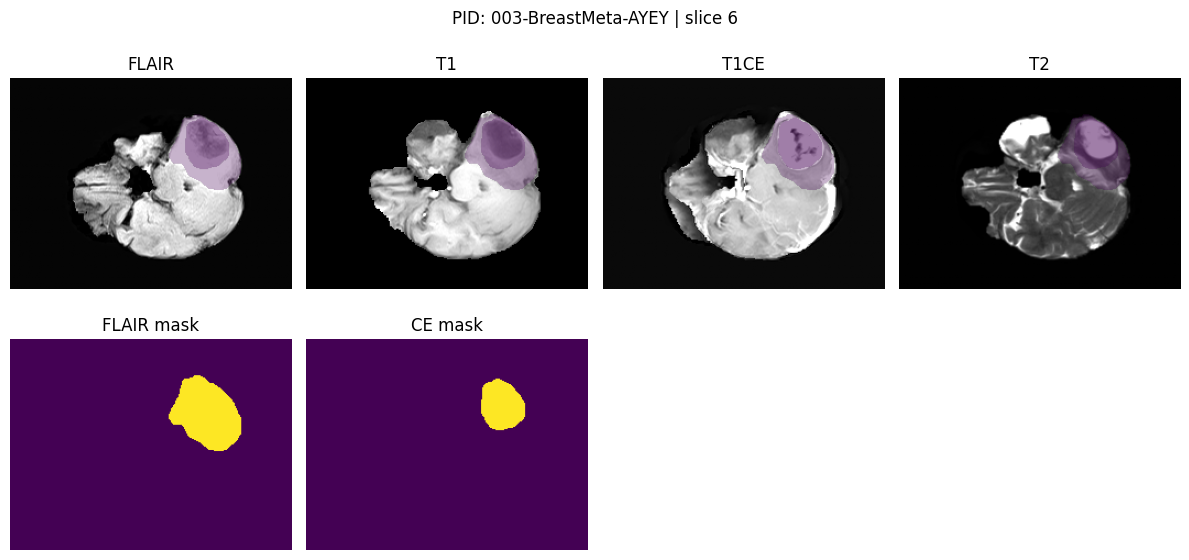

In [7]:
import os, json, random, glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/MOTUM-v.2.2"
IMAGES_DIR = os.path.join(BASE, "images")
DERIV_DIR  = os.path.join(BASE, "derivatives")

print("BASE:", BASE)
print("IMAGES_DIR exists:", os.path.isdir(IMAGES_DIR))
print("DERIV_DIR  exists:", os.path.isdir(DERIV_DIR))
print("---------------------------------------------------------------")

def pick_path(folder, basename):
    gz = os.path.join(folder, basename + ".nii.gz")
    ni = os.path.join(folder, basename + ".nii")
    if os.path.isfile(gz): return gz
    if os.path.isfile(ni): return ni
    return None

patients = sorted([p for p in os.listdir(IMAGES_DIR) if os.path.isdir(os.path.join(IMAGES_DIR, p))])
usable, missing = [], {}

for pid in patients:
    img_dir, der_dir = os.path.join(IMAGES_DIR, pid), os.path.join(DERIV_DIR, pid)
    flair, t1, t1ce, t2 = [pick_path(img_dir, m) for m in ["flair", "t1", "t1ce", "t2"]]
    fl_lbl, ce_lbl = pick_path(der_dir, "flair_seg_label1"), pick_path(der_dir, "t1ce_seg_label2")
    need = {"flair": flair, "t1": t1, "t1ce": t1ce, "t2": t2, "flair_abn": fl_lbl, "ce_core": ce_lbl}
    miss = [k for k, v in need.items() if v is None]
    if miss: missing[pid] = miss
    else:
        usable.append({
            "patient_id": pid,
            "images": {k: need[k] for k in ["flair", "t1", "t1ce", "t2"]},
            "labels": {"flair_abn": need["flair_abn"], "ce_core": need["ce_core"]}
        })

DATA_DIR = os.path.join(BASE, "data")
os.makedirs(DATA_DIR, exist_ok=True)
dataset_json = {
    "name": "MOTUM",
    "modality_order": ["flair", "t1", "t1ce", "t2"],
    "labels": {"0": "background", "1": "FLAIR_abn", "2": "CE_core"},
    "numTraining": len(usable),
    "training": usable,
}
with open(os.path.join(DATA_DIR, "dataset.json"), "w") as f:
    json.dump(dataset_json, f, indent=2)

print("Saved:", os.path.join(DATA_DIR, "dataset.json"))
print("Example entry:")
print(json.dumps(dataset_json["training"][0], indent=2) if usable else "No usable cases.")
print("---------------------------------------------------------------")

# 5-fold splits
SPLIT_DIR = os.path.join(DATA_DIR, "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)
random.seed(42)
ids = [it["patient_id"] for it in usable]
random.shuffle(ids)
K = 5
folds = [ids[i::K] for i in range(K)]
splits = []
for k in range(K):
    val_ids = set(folds[k])
    train_ids = [pid for pid in ids if pid not in val_ids]
    splits.append({"fold": k, "train": train_ids, "val": list(val_ids)})

with open(os.path.join(SPLIT_DIR, "splits_5fold.json"), "w") as f:
    json.dump(splits, f, indent=2)

for s in splits:
    print(f"Fold {s['fold']}: train={len(s['train'])}, val={len(s['val'])}")
print("---------------------------------------------------------------")

# visualization of one patient
ds_json = json.load(open(os.path.join(DATA_DIR, "dataset.json")))
case = random.choice(ds_json["training"])
pid = case["patient_id"]
paths = case["images"]
lbls  = case["labels"]

def load_nii(p):
    arr = nib.load(p).get_fdata().astype(np.float32)
    m, M = np.percentile(arr, 1), np.percentile(arr, 99)
    return np.clip((arr - m) / (M - m + 1e-6), 0, 1)

flair, t1, t1ce, t2 = [load_nii(paths[m]) for m in ["flair", "t1", "t1ce", "t2"]]
lab_fl = nib.load(lbls["flair_abn"]).get_fdata().astype(np.uint8)
lab_ce = nib.load(lbls["ce_core"]).get_fdata().astype(np.uint8)

k = int(np.argmax((lab_fl + lab_ce).sum(axis=(0, 1))))

def show_panel(vols, titles, k, lab_fl=None, lab_ce=None):
    plt.figure(figsize=(12, 6))
    for i, (v, t) in enumerate(zip(vols, titles), 1):
        plt.subplot(2, 4, i)
        plt.imshow(v[:, :, k], cmap="gray")
        plt.title(t)
        plt.axis("off")
        if lab_fl is not None:
            m = np.ma.masked_where(lab_fl[:, :, k] == 0, lab_fl[:, :, k])
            plt.imshow(m, alpha=0.3)
        if lab_ce is not None:
            m = np.ma.masked_where(lab_ce[:, :, k] == 0, lab_ce[:, :, k])
            plt.imshow(m, alpha=0.3)
    plt.subplot(2, 4, 5)
    plt.imshow(lab_fl[:, :, k], vmin=0, vmax=1)
    plt.title("FLAIR mask")
    plt.axis("off")
    plt.subplot(2, 4, 6)
    plt.imshow(lab_ce[:, :, k], vmin=0, vmax=1)
    plt.title("CE mask")
    plt.axis("off")
    plt.suptitle(f"PID: {pid} | slice {k}")
    plt.tight_layout()
    plt.show(block=True)

show_panel([flair, t1, t1ce, t2], ["FLAIR", "T1", "T1CE", "T2"], k, lab_fl, lab_ce)


In [8]:
import json, re

dataset_path = f"{BASE}/data/dataset.json"

with open(dataset_path, "r") as f:
    data = json.load(f)

def fix_path(p):
    p = p.replace("G:\\My Drive\\", "/content/drive/MyDrive/")
    p = p.replace("\\", "/")
    return p

for item in data["training"]:
    for k, v in item["images"].items():
        item["images"][k] = fix_path(v)
    for k, v in item["labels"].items():
        item["labels"][k] = fix_path(v)

with open(dataset_path, "w") as f:
    json.dump(data, f, indent=2)

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q monai-weekly nibabel simpleitk torchio scikit-image tqdm matplotlib tensorboard rich ml-collections

In [9]:
import os, json, time, warnings
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from monai.data import CacheDataset, DataLoader
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, RandFlipd, RandAffined,
    RandGaussianNoised, RandAdjustContrastd, EnsureTyped,
    RandCropByPosNegLabeld, SpatialPadd, AsDiscrete
)
from monai.losses import DiceLoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.inferers import sliding_window_inference
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score
from torch.amp import autocast, GradScaler
from monai.networks.nets import DynUNet
from monai.networks.layers import Norm

warnings.filterwarnings("ignore")

DATASET_JSON = f"{BASE}/data/dataset.json"
SPLITS_JSON  = f"{BASE}/data/splits/splits_5fold.json"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(DATASET_JSON) as f:
    DS = json.load(f)
with open(SPLITS_JSON) as f:
    SPLITS = json.load(f)

def build_lists(fold: int, setup: str):
    all_items = DS["training"]
    fold_info = [s for s in SPLITS if s["fold"] == fold][0]
    tr_ids, va_ids = set(fold_info["train"]), set(fold_info["val"])

    def sel_channels(imgs):
        if setup == "t1ce":
            return {"im": [imgs["t1ce"]]}
        elif setup == "t1ce_flair":
            return {"im": [imgs["t1ce"], imgs["flair"]]}
        elif setup == "all4":
            return {"im": [imgs[m] for m in ["flair", "t1", "t1ce", "t2"]]}
        else:
            raise ValueError("Unknown setup")

    train_list, val_list = [], []
    for it in all_items:
        sample = {
            "pid": it["patient_id"],
            "label_ce": it["labels"]["ce_core"],
            "label_fl": it["labels"]["flair_abn"],
        }
        sample.update(sel_channels(it["images"]))
        (train_list if it["patient_id"] in tr_ids else val_list).append(sample)
    return train_list, val_list


def get_transforms(patch_size=(128,128,128)):
    common = [
        LoadImaged(keys=["im","label_ce","label_fl"]),
        EnsureChannelFirstd(keys=["im","label_ce","label_fl"]),
        Orientationd(keys=["im","label_ce","label_fl"], axcodes="RAS"),
        Spacingd(keys=["im","label_ce","label_fl"], pixdim=(1,1,1), mode=("bilinear","nearest","nearest")),
        NormalizeIntensityd(keys=["im"], nonzero=True, channel_wise=True),
        EnsureTyped(keys=["im","label_ce","label_fl"]),
    ]
    train_aug = [
        SpatialPadd(keys=["im","label_ce","label_fl"], spatial_size=patch_size),
        RandCropByPosNegLabeld(keys=["im","label_ce","label_fl"], label_key="label_ce",
                               spatial_size=patch_size, pos=4, neg=1, num_samples=2),
        RandFlipd(keys=["im","label_ce","label_fl"], prob=0.5, spatial_axis=(0,1,2)),
        RandAffined(keys=["im","label_ce","label_fl"], prob=0.2,
                    rotate_range=(0.1,0.1,0.1), scale_range=(0.1,0.1,0.1),
                    mode=("bilinear","nearest","nearest")),
        RandAdjustContrastd(keys=["im"], prob=0.15, gamma=(0.7,1.5)),
        RandGaussianNoised(keys=["im"], prob=0.15, mean=0.0, std=0.01),
        EnsureTyped(keys=["im","label_ce","label_fl"]),
    ]
    val_aug = [
        SpatialPadd(keys=["im","label_ce","label_fl"], spatial_size=patch_size),
        RandCropByPosNegLabeld(
            keys=["im","label_ce","label_fl"],
            label_key="label_ce",
            spatial_size=patch_size,
            pos=4, neg=1, num_samples=1
        ),
        EnsureTyped(keys=["im","label_ce","label_fl"]),
    ]
    return Compose(common + train_aug), Compose(common + val_aug)


def merge_labels_collate(batch):
    from torch.utils.data.dataloader import default_collate
    if isinstance(batch[0], list):
        batch = [item for sublist in batch for item in sublist]
    b = default_collate(batch)

    label = torch.zeros_like(b["label_ce"], dtype=torch.long).squeeze(1)
    fl = b["label_fl"].squeeze(1).long()
    ce = b["label_ce"].squeeze(1).long()

    label = label + (fl>0).long()*1
    label = torch.where(ce>0, torch.tensor(2, device=label.device), label)

    if torch.sum(label) == 0:
        print("Empty label mask, skipping augmentation")

    b["label"] = label
    b.pop("label_ce", None)
    b.pop("label_fl", None)
    return b


def make_dataloaders(fold=0, setup="t1ce", patch_size=(128,128,128),
                     batch_size=1, num_workers=2, cache_rate=0.0):
    tr, va = build_lists(fold, setup)
    tr_tf, va_tf = get_transforms(patch_size)
    tr_ds = CacheDataset(tr, tr_tf, cache_rate, num_workers)
    va_ds = CacheDataset(va, va_tf, cache_rate, num_workers)
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                           num_workers=num_workers, pin_memory=True, collate_fn=merge_labels_collate)
    va_loader = DataLoader(va_ds, batch_size=1, shuffle=False,
                           num_workers=num_workers, pin_memory=True, collate_fn=merge_labels_collate)
    return tr_loader, va_loader


# model, loss, optimizer
def make_model(n_channels, n_classes=3, base_filters=32):
    return DynUNet(
        spatial_dims=3,
        in_channels=n_channels,
        out_channels=n_classes,
        kernel_size=[3,3,3,3,3,3],
        strides=[1,2,2,2,2,2],
        upsample_kernel_size=[2,2,2,2,2],
        filters=[base_filters, base_filters*2, base_filters*4, base_filters*8, base_filters*16, base_filters*32],
        dropout=0.1,
        norm_name="instance",
        act_name=("leakyrelu", {"inplace": True, "negative_slope": 0.01}),
        deep_supervision=False
    ).to(DEVICE)



def make_loss():
    dice = DiceLoss(to_onehot_y=True, softmax=True, include_background=True)
    weights = torch.tensor([0.05, 0.45, 0.5]).to(DEVICE)
    def combined_loss(pred, target):
        loss_dice = dice(pred, target)
        loss_ce = F.cross_entropy(pred, target.squeeze(1).long(), weight=weights)
        return 0.3 * loss_dice + 0.7 * loss_ce
    return combined_loss

def make_optim(model, lr=1e-4, wd=1e-5):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

scaler = GradScaler("cuda")


# training, validation, metrics
def train_one_epoch(model, loader, opt, loss_fn):
    model.train(); run=0.0
    for b in loader:
        imgs=b["im"].to(DEVICE)
        lbl=b["label"].to(DEVICE).unsqueeze(1)
        opt.zero_grad()
        with autocast("cuda"):
            out=model(imgs)
            loss=loss_fn(out,lbl)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        run+=loss.item()
    return run/max(1,len(loader))


@torch.no_grad()
def validate(model, loader, roi_size=(96,96,96)):
    model.eval()
    dice_metric = DiceMetric(include_background=True, reduction="mean")
    total_time = 0.0
    dice_scores = []

    for batch in loader:
        imgs = batch["im"].to(DEVICE)
        labels = batch["label"].to(DEVICE).long()

        if imgs.ndim == 6:
            imgs = imgs.squeeze(2)

        labels_onehot = torch.nn.functional.one_hot(labels, num_classes=3)
        labels_onehot = labels_onehot.permute(0, 4, 1, 2, 3).float()

        t0 = time.time()
        preds = sliding_window_inference(imgs, roi_size=roi_size, sw_batch_size=1, predictor=model)
        preds = torch.softmax(preds, dim=1)
        total_time += time.time() - t0

        dice_batch = dice_metric(y_pred=preds, y=labels_onehot)
        scores = dice_metric.aggregate()
        dice_metric.reset()

        valid_scores = scores[~torch.isnan(scores)]
        if len(valid_scores) > 0:
            dice_scores.append(valid_scores.mean().item())

    mean_dice = sum(dice_scores) / max(1, len(dice_scores))
    mean_time = total_time / max(1, len(loader))
    return mean_dice, mean_time


@torch.no_grad()
def evaluate_metrics(model, loader, patch_size=(96,96,96)):
    model.eval()
    dice_metric = DiceMetric(include_background=False, reduction="none")
    hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95)
    threshold = AsDiscrete(argmax=True)

    all_dice, all_hd95, all_f1, all_iou, all_precision, all_recall = [], [], [], [], [], []

    for batch in loader:
        imgs = batch["im"].to(DEVICE)
        labels = batch["label"].to(DEVICE).long()
        if torch.sum(labels) == 0:
            continue

        preds = sliding_window_inference(imgs, roi_size=patch_size, sw_batch_size=1, predictor=model)
        preds = torch.softmax(preds, dim=1)
        preds_disc = threshold(preds)

        labels_onehot = torch.nn.functional.one_hot(labels, num_classes=3)
        labels_onehot = labels_onehot.permute(0, 4, 1, 2, 3).float()

        dsc = dice_metric(y_pred=preds_disc, y=labels_onehot)
        hd  = hd95_metric(y_pred=preds_disc, y=labels_onehot)

        mean_dsc = torch.nan_to_num(torch.nanmean(dsc), nan=0.0).item()
        mean_hd  = torch.nan_to_num(torch.nanmean(hd), nan=0.0).item()
        all_dice.append(mean_dsc)
        all_hd95.append(mean_hd)

        y_true = labels.cpu().numpy().ravel()
        y_pred = preds_disc.argmax(1).cpu().numpy().ravel()

        all_precision.append(precision_score(y_true, y_pred, average='macro', zero_division=0))
        all_recall.append(recall_score(y_true, y_pred, average='macro', zero_division=0))
        all_f1.append(f1_score(y_true, y_pred, average='macro', zero_division=0))
        all_iou.append(jaccard_score(y_true, y_pred, average='macro', zero_division=0))

    metrics = {
        "Dice": np.mean(all_dice),
        "F1": np.mean(all_f1),
        "IoU": np.mean(all_iou),
        "Precision": np.mean(all_precision),
        "Recall": np.mean(all_recall),
        "HD95": np.mean(all_hd95)
    }
    metrics = {k: np.nan_to_num(v, nan=0.0) for k,v in metrics.items()}
    return metrics

In [10]:
EPOCHS = 100
PATCH = (96,96,96)
BATCH = 1

SETUP = "t1ce_flair"
IN_CHANNELS = 2
BASE_FILTERS = 32
LR = 1e-4

tr, va = make_dataloaders(fold=0, setup=SETUP, patch_size=PATCH, batch_size=BATCH, num_workers=2, cache_rate=0.0)
model = make_model(n_channels=IN_CHANNELS, base_filters=BASE_FILTERS)
loss_fn = make_loss()
opt = make_optim(model, lr=LR)

train_losses, val_dices = [], []
epoch_metrics = {k: [] for k in ["Dice","F1","IoU","Precision","Recall","HD95"]}
best_dice = 0.0

print(f"{SETUP} | f={BASE_FILTERS} | lr={LR} | epochs={EPOCHS}")
print("----------------------------------------------------------")

for ep in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, tr, opt, loss_fn)
    val_dice, _ = validate(model, va, roi_size=PATCH)
    metrics = evaluate_metrics(model, va, patch_size=PATCH)

    train_losses.append(tr_loss)
    val_dices.append(val_dice)
    for k in epoch_metrics: epoch_metrics[k].append(metrics[k])

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), f"best_dynunet_{SETUP}.pth")

    print(f"Epoch {ep:03d}/{EPOCHS} | Train={tr_loss:.4f} | ValDice={val_dice:.4f} | "
          f"F1={metrics['F1']:.4f} | IoU={metrics['IoU']:.4f} | Prec={metrics['Precision']:.4f} | "
          f"Rec={metrics['Recall']:.4f} | HD95={metrics['HD95']:.4f}")

print("----------------------------------------------------------")
print(f"Best Dice: {best_dice:.4f}")

t1ce_flair | f=32 | lr=0.0001 | epochs=100
----------------------------------------------------------
Empty label mask, skipping augmentation
Epoch 001/100 | Train=0.8301 | ValDice=0.3977 | F1=0.3100 | IoU=0.2910 | Prec=0.2910 | Rec=0.3333 | HD95=0.0000
Empty label mask, skipping augmentation
Epoch 002/100 | Train=0.6970 | ValDice=0.4085 | F1=0.3122 | IoU=0.2946 | Prec=0.2946 | Rec=0.3333 | HD95=0.0000
Epoch 003/100 | Train=0.6426 | ValDice=0.3865 | F1=0.3105 | IoU=0.2919 | Prec=0.2919 | Rec=0.3333 | HD95=0.0000
Empty label mask, skipping augmentation
Empty label mask, skipping augmentation
Empty label mask, skipping augmentation
Empty label mask, skipping augmentation
Empty label mask, skipping augmentation
Epoch 004/100 | Train=0.6132 | ValDice=0.4713 | F1=0.3146 | IoU=0.2989 | Prec=0.2989 | Rec=0.3333 | HD95=0.0000
Empty label mask, skipping augmentation
Empty label mask, skipping augmentation
Epoch 005/100 | Train=0.5967 | ValDice=0.3980 | F1=0.3433 | IoU=0.3288 | Prec=0.3288 | Rec

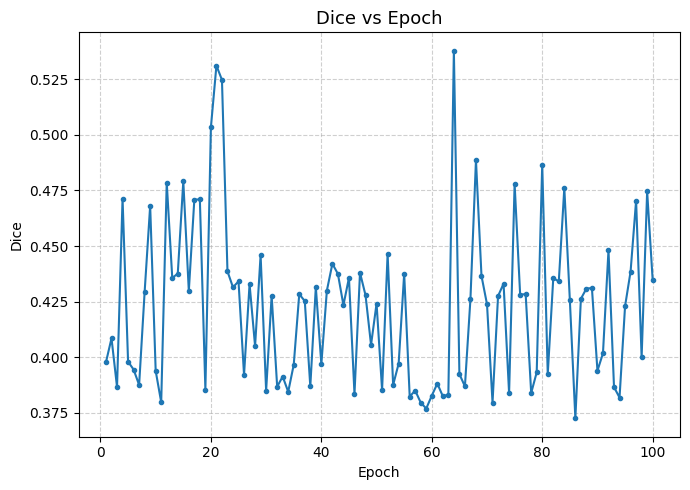

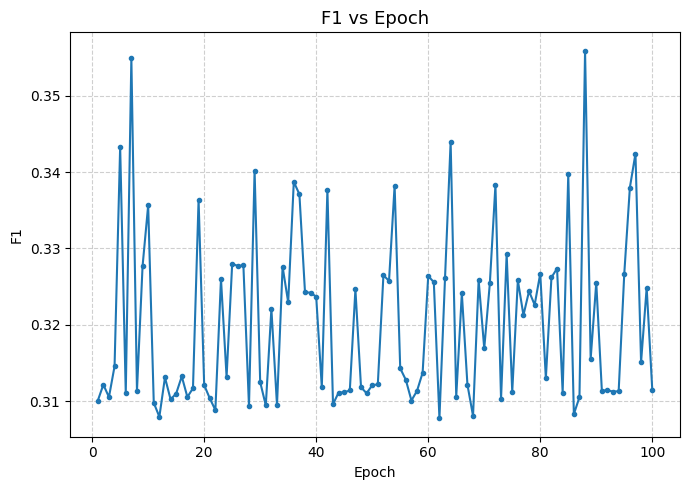

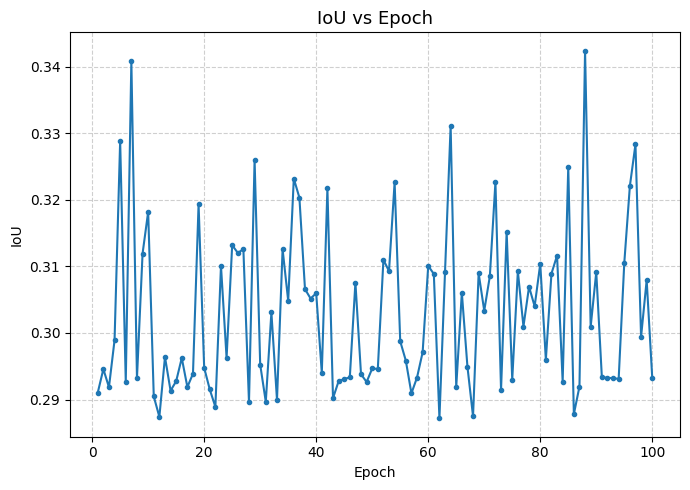

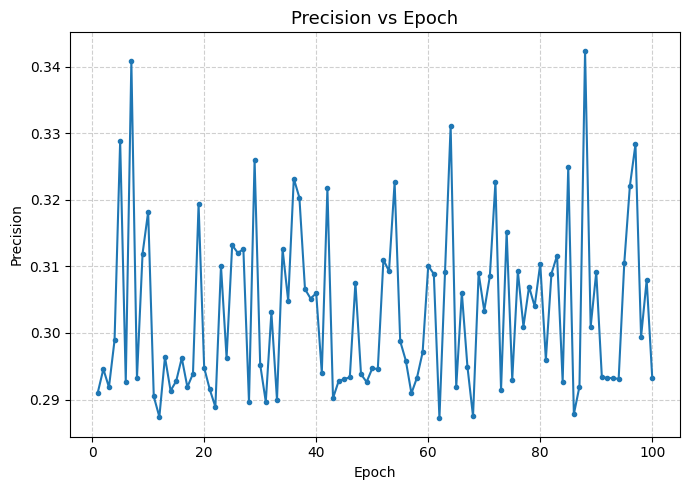

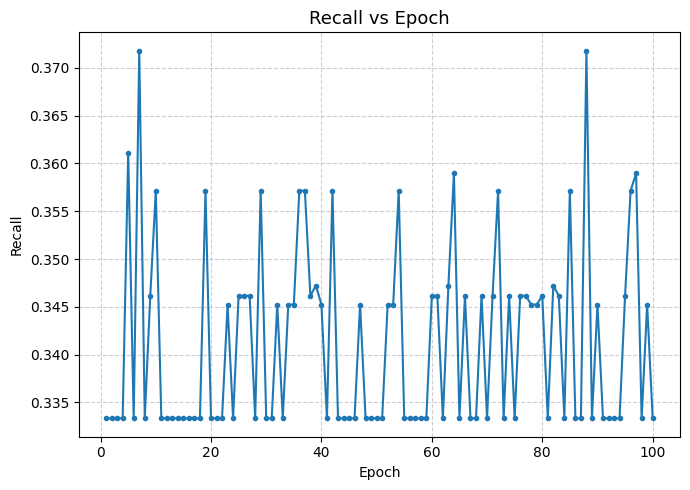

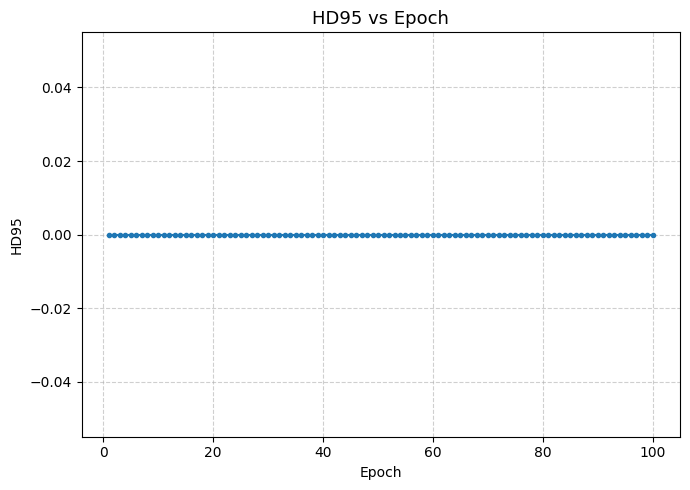

In [13]:
import matplotlib.pyplot as plt

epochs = list(range(1, EPOCHS + 1))
plt.figure(figsize=(7,5))
plt.plot(epochs, val_dices, marker='o', markersize=3)
plt.title("Dice vs Epoch", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

for metric_name, values in epoch_metrics.items():
    if metric_name.lower() == "dice":
        continue
    plt.figure(figsize=(7,5))
    plt.plot(epochs, values, marker='o', markersize=3)
    plt.title(f"{metric_name} vs Epoch", fontsize=13)
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
